# Thorlabs power-meter acquisition

This notebook uses `PMDevice.py` to discover and initialise a Thorlabs PMXXX power meter, configure the measurement, acquire readings for a user-defined duration, display progress, optionally save a CSV, and plot the completed run.

Keep `PMDevice.py` in the same folder as this notebook, or set `PMDEVICE_FOLDER` below. Run the cells in order. The device is disconnected automatically after acquisition, including after an error or keyboard interrupt.

In [9]:
# If needed once in a fresh environment:
# %pip install numpy pandas matplotlib tqdm

from pathlib import Path
from ctypes import c_uint32, c_int, c_char_p, byref, create_string_buffer
from datetime import datetime
import sys
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

PMDEVICE_FOLDER = Path('.')  # Folder containing PMDevice.py
if str(PMDEVICE_FOLDER.resolve()) not in sys.path:
    sys.path.insert(0, str(PMDEVICE_FOLDER.resolve()))

from PMDevice import PMDevice
print('PMDevice imported successfully.')

PMDevice imported successfully.


## Measurement settings

`sample_interval_s` is the requested time between the starts of successive reads. It should normally be at least as long as the meter's averaging time. Set `device_index` after checking the discovery-cell output.

In [51]:
settings = {
    'device_index': 0,
    'wavelength_nm': 1550.0,
    'unit': 'dBm',             # 'W' or 'dBm'
    'autorange': True,
    'average_time_s': 0.1,     # Passed to TLPMX setAvgTime
    'average_count': 1,        # Passed to TLPMX setAvgCnt
    'timeout_s': 5,
    'duration_s': 1800.0,
    'sample_interval_s': 1.0,
    'save_csv': True,
    'csv_filename': 'power_measurement.csv',
    'plot_linear': True,       # Power versus elapsed time
    'plot_histogram':False,
    'show_summary': True,
}

if settings['unit'] not in {'W', 'dBm'}:
    raise ValueError("unit must be 'W' or 'dBm'")
if settings['duration_s'] <= 0 or settings['sample_interval_s'] <= 0:
    raise ValueError('duration_s and sample_interval_s must be positive')
if settings['average_count'] < 1:
    raise ValueError('average_count must be at least 1')

settings

{'device_index': 0,
 'wavelength_nm': 1550.0,
 'unit': 'dBm',
 'autorange': True,
 'average_time_s': 0.1,
 'average_count': 1,
 'timeout_s': 5,
 'duration_s': 1800.0,
 'sample_interval_s': 1.0,
 'save_csv': True,
 'csv_filename': 'power_measurement.csv',
 'plot_linear': True,
 'plot_histogram': False,
 'show_summary': True}

## Discover and select the device

In [52]:
def discover_devices(pm):
    """Return TLPMX resource names (works around PMDevice.find_devices not returning its list)."""
    count = c_uint32()
    status = pm.device.findRsrc(byref(count))
    if status != 0:
        raise RuntimeError(f'findRsrc failed: {status}')

    names = []
    for index in range(count.value):
        buffer = create_string_buffer(1024)
        status = pm.device.getRsrcName(c_int(index), buffer)
        if status != 0:
            raise RuntimeError(f'getRsrcName({index}) failed: {status}')
        names.append(c_char_p(buffer.raw).value.decode())
    return names

pm = PMDevice()
resource_names = discover_devices(pm)
if not resource_names:
    raise RuntimeError('No compatible Thorlabs power meter was found.')

for index, name in enumerate(resource_names):
    marker = '  <-- selected' if index == settings['device_index'] else ''
    print(f'[{index}] {name}{marker}')

if not 0 <= settings['device_index'] < len(resource_names):
    raise IndexError('device_index is outside the discovered-device list')

# PMDevice.connect() expects this ctypes buffer. Setting it here enables explicit selection.
selected_resource = resource_names[settings['device_index']]
pm.resources = create_string_buffer(selected_resource.encode())
print(f'Will connect to: {selected_resource}')

[0] USB0::0x1313::0x80B4::250214211::INSTR  <-- selected
Will connect to: USB0::0x1313::0x80B4::250214211::INSTR


## Connect and configure

In [53]:
try:
    pm.connect()
    pm.newTimeOut(settings['timeout_s'])
    pm.set_wavelength(settings['wavelength_nm'])
    pm.set_autorange(settings['autorange'])
    pm.set_unit(settings['unit'])
    pm.SetAvMeasureTime(settings['average_time_s'])
    pm.SetAvMeasure(settings['average_count'])
    time.sleep(0.5)
    test_value = pm.read_power()
    print(f'Configuration complete. Test reading: {test_value:.6g} {settings["unit"]}')
except Exception:
    pm.disconnect()
    raise

Device connected
Last calibration date: 14-FEB-2025 

Units set to dBm
Configuration complete. Test reading: -0.849795 dBm


## Timed acquisition

The loop uses a monotonic clock and fixed target times to reduce cumulative timing drift. The final reading occurs before—not after—the requested duration.

In [54]:
def acquire_for_duration(pm, duration_s, interval_s, unit):
    planned_samples = max(1, int(np.ceil(duration_s / interval_s)))
    rows = []
    start_mono = time.monotonic()

    with tqdm(total=duration_s, unit='s', desc='Measuring', dynamic_ncols=True) as bar:
        try:
            sample_indices = range(planned_samples)
            for sample_index in sample_indices:
                target = start_mono + sample_index * interval_s
                remaining = target - time.monotonic()
                if remaining > 0:
                    time.sleep(remaining)

                elapsed_before_read = time.monotonic() - start_mono
                if sample_index > 0 and elapsed_before_read >= duration_s:
                    break

                value = pm.read_power()
                elapsed = time.monotonic() - start_mono
                rows.append({
                    'timestamp': datetime.now(),
                    'elapsed_s': elapsed,
                    f'power_{unit}': value,
                })
                bar.n = min(elapsed, duration_s)
                bar.set_postfix(reading=f'{value:.6g} {unit}', samples=len(rows))
                bar.refresh()
        except KeyboardInterrupt:
            bar.write('Acquisition stopped by user; retaining completed readings.')

        bar.n = duration_s
        bar.refresh()

    return pd.DataFrame(rows)

try:
    data = acquire_for_duration(
        pm,
        duration_s=settings['duration_s'],
        interval_s=settings['sample_interval_s'],
        unit=settings['unit'],
    )
finally:
    pm.disconnect()

if 'data' not in globals() or data.empty:
    raise RuntimeError('No measurements were collected.')

if settings['save_csv']:
    output_path = Path(settings['csv_filename']).expanduser().resolve()
    data.to_csv(output_path, index=False)
    print(f'Saved {len(data)} measurements to {output_path}')
else:
    print(f'Collected {len(data)} measurements (CSV saving disabled).')

data.head()

Measuring:   0%|          | 0/1800.0 [00:00<?, ?s/s]

Power meter disconnected.

Saved 1800 measurements to C:\Users\Experiment\Documents\Python\VQ_Instruments\my_modules\power_measurement.csv


,timestamp,elapsed_s,power_dBm
0,2026-08-18 15:43:58.407427,0.022257,-0.941099
1,2026-08-18 15:43:59.388480,1.003310,-0.937725
2,2026-08-18 15:44:00.387089,2.001920,-0.937046
3,2026-08-18 15:44:01.388166,3.002996,-0.944090
4,2026-08-18 15:44:02.387091,4.001921,-0.946229


## Summary and optional plots

,value
count,1800.000000
mean,-0.928105
std,0.007709
min,-0.953151
max,-0.905516


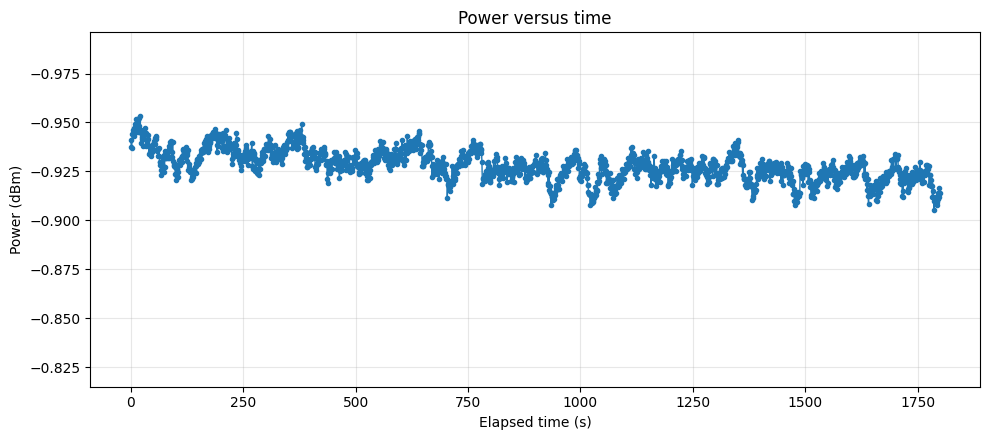

In [55]:
power_column = f'power_{settings["unit"]}'

if settings['show_summary']:
    summary = data[power_column].agg(['count', 'mean', 'std', 'min', 'max']).to_frame('value')
    display(summary)

if settings['plot_linear']:
    fig, ax = plt.subplots(figsize=(10, 4.5))
    ax.plot(data['elapsed_s'], data[power_column], marker='o', ms=3, lw=1)
    ax.set(xlabel='Elapsed time (s)', ylabel=f'Power ({settings["unit"]})', title='Power versus time')
    ax.grid(True, alpha=0.3)
    ax.set_ylim([np.max(data[power_column])*(1-0.1),(1+.1)*np.max(data[power_column])])
    fig.tight_layout()
    plt.show()

if settings['plot_histogram']:
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.hist(data[power_column].dropna(), bins='auto', edgecolor='black', alpha=0.75)
    ax.set(xlabel=f'Power ({settings["unit"]})', ylabel='Count', title='Distribution of measured power')
    ax.grid(True, axis='y', alpha=0.3)
    fig.tight_layout()
    plt.show()

## Manual disconnect (optional)

The acquisition cell already disconnects the meter. Use the following only if you stopped execution during configuration.

In [ ]:
# pm.disconnect()